### Import necessary libraries

In [ ]:
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For data visualization

# Import machine learning modules
from sklearn.model_selection import train_test_split, GridSearchCV  # For data splitting and hyperparameter tuning
from sklearn.svm import SVR  # Support Vector Regression model
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.metrics import mean_squared_error, r2_score  # For evaluating model performance
from sklearn.feature_selection import SelectKBest, f_regression  # For feature selection based on statistical tests


### Load the dataset from a CSV file into a Pandas Dataframe

In [ ]:
df = pd.read_csv('Latest Covid-19 India Status.csv')  # Adjust the file path as needed

### Step 1: Inspect dataset and handle missing values

In [ ]:
df.fillna(0, inplace=True)  # Fill missing values with 0 (or use other imputation methods)

#### Step 2: Feature Engineering

In [ ]:
# Create a new column for active cases per million population
df['Active per Million'] = df['Active'] / df['Population'] * 1e6

# Create a new column for discharged (recovered) cases per million population
df['Discharged per Million'] = df['Discharged'] / df['Population'] * 1e6

# Create a new column for deaths per million population
df['Deaths per Million'] = df['Deaths'] / df['Population'] * 1e6

# Create a new column for total cases per million population
df['Cases per Million'] = df['Total Cases'] / df['Population'] * 1e6

# Calculate the growth rate of total cases (percentage change from the previous row) and fill NaN values with 0
df['Growth Rate'] = df['Total Cases'].pct_change().fillna(0)

#### Adding Moving Averages for Trend Analysis

In [ ]:
# Calculate the 7-day moving average for total cases to smooth short-term fluctuations
df['7_day_avg_cases'] = df['Total Cases'].rolling(window=7).mean().fillna(0)

# Calculate the 7-day moving average for deaths to observe trends in fatalities
df['7_day_avg_deaths'] = df['Deaths'].rolling(window=7).mean().fillna(0)


#### Adding Lag Features for Temporal Dependency

In [ ]:
# Create a lag feature for total cases from the previous day to capture short-term trends
df['Lag_1_day_cases'] = df['Total Cases'].shift(1).fillna(0)

# Create a lag feature for total cases from the previous week to analyze weekly patterns
df['Lag_7_day_cases'] = df['Total Cases'].shift(7).fillna(0)


#### Log Transformation to Handle Skewness

In [ ]:
# Apply log transformation to total cases to reduce skewness and handle large variations in data
# Adding 1 ensures we avoid log(0), which is undefined
df['Log_Total_Cases'] = np.log(df['Total Cases'] + 1)


#### Step 3: Prepare Features (X) and Target Variable (y)

In [ ]:
# Select relevant features (independent variables) for model training
X = df[['Total Cases', 'Active', 'Discharged', 'Deaths', 'Population',
        'Active per Million', 'Discharged per Million', 'Deaths per Million',
        'Cases per Million', 'Growth Rate', '7_day_avg_cases', '7_day_avg_deaths',
        'Log_Total_Cases', 'Lag_1_day_cases', 'Lag_7_day_cases']]

# Define the target variable (dependent variable) as 'Active' cases for prediction
y = df['Active']

#### Step 4: Split the Data into Training and Testing Sets

In [ ]:
# Split the dataset into training (80%) and testing (20%) subsets
# `random_state=42` ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Step 5: Standardize Features Using StandardScaler

In [ ]:
# Initialize the StandardScaler to normalize feature values
scaler = StandardScaler()

# Fit the scaler on the training data and transform it to have zero mean and unit variance
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to the test data using the previously fitted scaler
X_test = scaler.transform(X_test)


#### Step 6: Feature Selection Using SelectKBest with f_regression

In [ ]:
# Initialize SelectKBest with f_regression as the scoring function and set to select top 10 features
selector = SelectKBest(f_regression, k=10)

# Fit the feature selector on the training data and transform X_train to keep only the top 10 features
X_train = selector.fit_transform(X_train, y_train)

# Apply the same feature selection transformation on the test data
X_test = selector.transform(X_test)


#### Step 7: Hyperparameter Tuning Using GridSearchCV for SVM

In [ ]:
# Define the parameter grid for tuning the SVM model's hyperparameters
param_grid = {
    'C': [0.1, 1, 10, 50, 100],  # Regularization parameter; controls the trade-off between a large margin and misclassification
    'epsilon': [0.01, 0.05, 0.1],  # Epsilon value for the margin of tolerance in regression
    'kernel': ['rbf', 'poly', 'linear'],  # The kernel types for the SVM; 'rbf' is the Radial Basis Function, 'poly' is polynomial, 'linear' is linear
    'gamma': ['scale', 'auto', 0.1, 0.5],  # Kernel coefficient for 'rbf', 'poly', and 'sigmoid'; 'scale' and 'auto' are automatic options
}


##### Perform GridSearchCV to Find the Best Hyperparameters for SVM

In [ ]:
# Initialize GridSearchCV with the Support Vector Regression model (SVR) and the defined parameter grid
# cv=5 performs 5-fold cross-validation, scoring='neg_mean_squared_error' selects the model with the lowest mean squared error
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit the GridSearchCV to the training data to find the best hyperparameters
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 180 candidates, totalling 900 fits


GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 50, 100],
                         'epsilon': [0.01, 0.05, 0.1],
                         'gamma': ['scale', 'auto', 0.1, 0.5],
                         'kernel': ['rbf', 'poly', 'linear']},
             scoring='neg_mean_squared_error', verbose=2)

##### Step 8: Retrieve the Best Model from GridSearchCV

In [ ]:
# Get the best estimator (model) from the GridSearchCV result, based on the best hyperparameters found
best_svm_model = grid_search.best_estimator_


##### Step 9: Predict on the Test Set

In [ ]:
# Use the best SVM model to make predictions on the test set
y_pred = best_svm_model.predict(X_test)


##### Step 10: Calculate R2 Score and Mean Squared Error (MSE)

In [ ]:
# Calculate the R2 score to measure the proportion of variance explained by the model (goodness of fit)
r2 = r2_score(y_test, y_pred)

# Calculate the Mean Squared Error (MSE) to measure the average squared difference between actual and predicted values
mse = mean_squared_error(y_test, y_pred)


##### Calculate Accuracy Based on 5% Error Threshold

In [ ]:
# Set the accuracy threshold to 5% (i.e., predictions within 5% of the actual values are considered accurate)
accuracy_threshold = 0.05

# Calculate the percentage of predictions where the absolute error is less than the 5% threshold
accuracy = np.mean(np.abs(y_pred - y_test) / y_test < accuracy_threshold) * 100


##### Output the Results

In [ ]:
# Print the best hyperparameters found by GridSearchCV for the SVM model
print(f'Best Parameters: {grid_search.best_params_}')

# Print the R2 score to evaluate the model's goodness of fit
print(f'R2 Score: {r2}')

# Print the Mean Squared Error (MSE) to assess the prediction error
print(f'Mean Squared Error: {mse}')

# Print the accuracy (percentage of predictions within 5% of actual value)
print(f'Accuracy (within 5%): {accuracy:.2f}%')


Best Parameters: {'C': 100, 'epsilon': 0.05, 'gamma': 'scale', 'kernel': 'linear'}
R2 Score: 0.9999947112762383
Mean Squared Error: 0.009943792307759242
Accuracy (within 5%): 62.50%


##### Step 11: Visualizing Model Performance

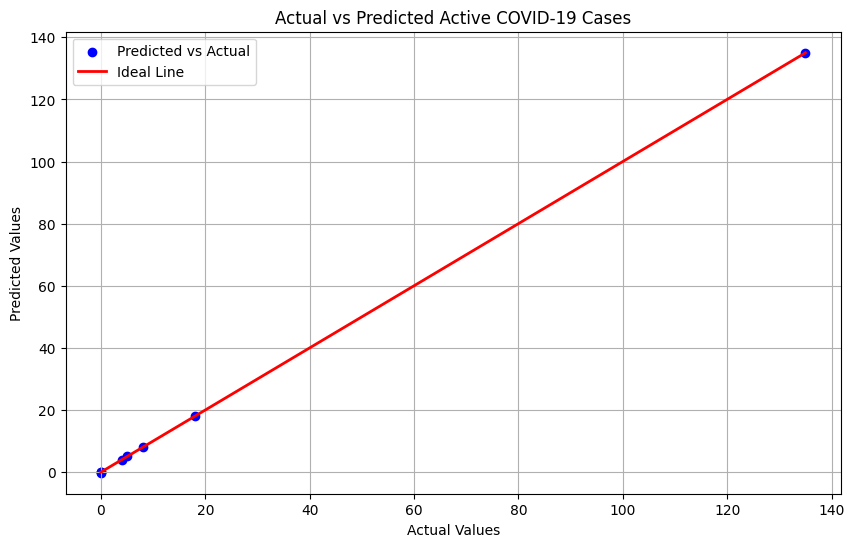

In [ ]:
# Create a scatter plot to compare the actual vs predicted values
plt.figure(figsize=(10, 6))  # Set the figure size for the plot
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')  # Plot the actual vs predicted values as points

# Add an ideal line (45-degree line) representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Ideal Line')

# Label the x-axis as "Actual Values"
plt.xlabel('Actual Values')

# Label the y-axis as "Predicted Values"
plt.ylabel('Predicted Values')

# Set the title for the plot
plt.title('Actual vs Predicted Active COVID-19 Cases')

# Display the legend to label the plot and ideal line
plt.legend()

# Add grid lines to make the plot easier to read
plt.grid(True)

# Show the plot
plt.show()


##### Step 12: Residual Plot (Actual - Predicted Values)

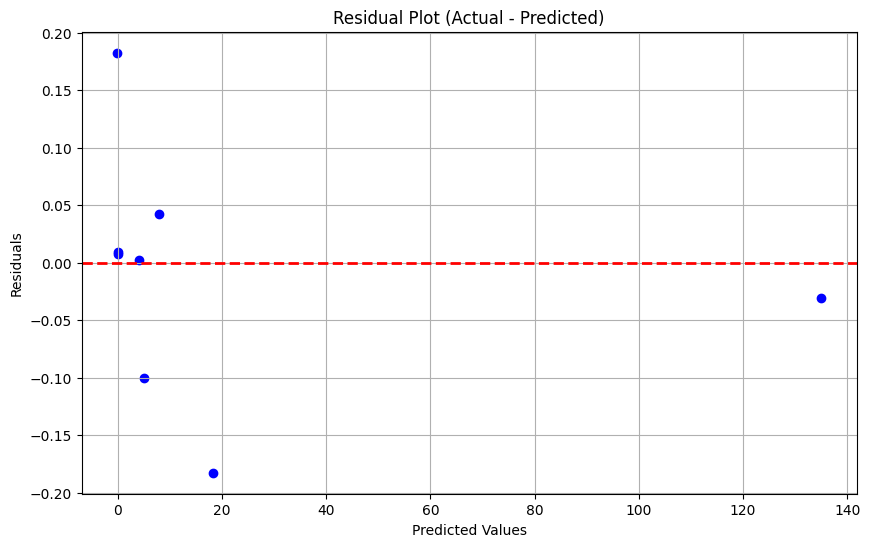

In [ ]:
# Calculate the residuals (differences between actual and predicted values)
residuals = y_test - y_pred

# Create a new figure for the residual plot
plt.figure(figsize=(10, 6))

# Plot the predicted values against the residuals as blue scatter points
plt.scatter(y_pred, residuals, color='blue')

# Add a horizontal line at y=0 to represent the baseline (no error)
plt.axhline(y=0, color='red', linestyle='--', lw=2)

# Label the x-axis as "Predicted Values"
plt.xlabel('Predicted Values')

# Label the y-axis as "Residuals"
plt.ylabel('Residuals')

# Set the title for the residual plot
plt.title('Residual Plot (Actual - Predicted)')

# Add grid lines for better readability
plt.grid(True)

# Display the plot
plt.show()


###### Step 13: Check Model Performance Based on R2 Score

In [ ]:
# Check if the R2 score is greater than 0.8 (80%), which is considered a good model performance
if r2 > 0.8:
    # Print a message indicating the model is performing well if the R2 score is above 80%
    print("Model is performing well with an R2 score greater than 80%")
else:
    # Print a message suggesting improvements if the R2 score is below 80%
    print("Model R2 score is below 80%, consider improving the features or model")


Model is performing well with an R2 score greater than 80%
